# Mini Projet — Gestion du déséquilibre de classes
## ETAPE 5— Stratégie 2 : Rééquilibrage dans l'Espace des Embeddings
### ✅ Version Google Colab — GPU Ready
**Module :** Machine Learning | **Enseignante :** Dr. Soraya Cheriguene  
**Université :** USDB — Master 1 SD & TAL | **Année :** 2025–2026

---
## AVANT DE COMMENCER — Checklist Colab
1. `Runtime → Change runtime type → T4 GPU → Save`
2. Exécuter les cellules dans l'ordre
3. Avoir les fichiers `train_set.csv`, `val_set.csv`, `test_set.csv` prêts à uploader

## CELLULE 1 — Installation des dépendances

In [51]:
import numpy
if numpy.__version__ != '1.26.4':
  !pip install numpy==1.26.4 --upgrade
  print("Restarting runtime to apply numpy version change...")
  import os
  os.kill(os.getpid(), 9)



## CELLULE 2 — Upload des fichiers CSV depuis ta machine

In [52]:
# ─── Upload des fichiers produits par l'Étape 2 ─────────────
# Une fenêtre va s'ouvrir → sélectionne les 3 fichiers :
#   train_set.csv  |  val_set.csv  |  test_set.csv
from google.colab import files
print("Sélectionne les 3 fichiers CSV (train_set, val_set, test_set)...")
uploaded = files.upload()

import os
print("\nFichiers disponibles :")
for f in os.listdir('.'):
    if f.endswith('.csv'):
        print(f"  ✅ {f}")

# Vérification que les 3 fichiers sont bien là
required = ['train_set.csv', 'val_set.csv', 'test_set.csv']
missing  = [f for f in required if not os.path.exists(f)]
if missing:
    print(f"\n⚠️  Fichiers manquants : {missing}")
else:
    print("\n✅ Tous les fichiers sont présents — tu peux continuer !")

Sélectionne les 3 fichiers CSV (train_set, val_set, test_set)...


Saving test_set.csv to test_set (1).csv
Saving train_set.csv to train_set (1).csv
Saving val_set.csv to val_set (1).csv

Fichiers disponibles :
  ✅ train_set.csv
  ✅ test_set.csv
  ✅ val_set.csv
  ✅ val_set (1).csv
  ✅ train_set (1).csv
  ✅ test_set (1).csv

✅ Tous les fichiers sont présents — tu peux continuer !


## CELLULE 3 — Imports et configuration

In [53]:
import os
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
warnings.filterwarnings('ignore')

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup
)
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score
)
from sklearn.preprocessing import label_binarize

# ─── Seed global obligatoire ────────────────────────────────
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

# ─── Device ─────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"✅ GPU détecté : {torch.cuda.get_device_name(0)}")
else:
    print("⚠️  Pas de GPU — vas dans Runtime → Change runtime type → T4 GPU")

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
print("\n✅ Imports OK")

Device : cuda
✅ GPU détecté : Tesla T4

✅ Imports OK


## CELLULE 4 — Chargement des données

In [54]:
df_train = pd.read_csv('train_set.csv')
df_val   = pd.read_csv('val_set.csv')
df_test  = pd.read_csv('test_set.csv')

print(f"Train : {len(df_train)} tweets")
print(f"Val   : {len(df_val)} tweets")
print(f"Test  : {len(df_test)} tweets")

LABEL2ID = {'Negative': 0, 'Neutral': 1, 'Positive': 2}
ID2LABEL = {v: k for k, v in LABEL2ID.items()}
NUM_LABELS = 3
CLASS_NAMES = ['Negative', 'Neutral', 'Positive']

for df in [df_train, df_val, df_test]:
    if 'label_id' not in df.columns:
        df['label_id'] = df['label'].map(LABEL2ID)



Train : 3512 tweets
Val   : 753 tweets
Test  : 753 tweets


Charger DziriBERT en mode extraction de features (sans la tête de classification)

Pour chaque tweet du train set, passer le texte dans DziriBERT et récupérer le vecteur
[CLS]

• Stocker ces vecteurs dans une matrice de forme (N, 768) où N est le nombre de tweets


• Ne jamais extraire les embeddings du val set ou du test set pour le rééquilibrage

In [55]:
from transformers import AutoModel, AutoTokenizer
import torch
import numpy as np

MODEL_NAME = "alger-ia/dziribert"
dziri_model = AutoModel.from_pretrained(MODEL_NAME)
dziri_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def get_cls_embedding(text):
    inputs = dziri_tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        outputs = dziri_model(**inputs)
    # Le vecteur [CLS] est la première position
    cls_vector = outputs.last_hidden_state[:,0,:].cpu().numpy()
    return cls_vector

# Extraire tous les embeddings du train set
embeddings = np.vstack([get_cls_embedding(t) for t in df_train['text'].tolist()])
labels = df_train['label_id'].values
print("Shape des embeddings :", embeddings.shape)  # (N, 768)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertModel LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
pooler.dense.bias                          | MISSING    | 
pooler.dense.weight                        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Shape des embeddings : (3512, 768)


## CELLULE 6 — Fonctions d'entraînement et métriques

In [56]:
NUM_EPOCHS   = 5
LR           = 2e-5
WARMUP_RATIO = 0.1

set_seed()

BATCH_SIZE = 16
MAX_LEN = 128

# Custom Dataset class for text data
class TweetDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

print(f"Chargement de DziriBERT ({MODEL_NAME})...")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
    ignore_mismatched_sizes=True
).to(DEVICE)

train_dataset = TweetDataset(
    texts=df_train['text'].to_list(),
    labels=df_train['label_id'].to_list(),
    tokenizer=dziri_tokenizer,
    max_len=MAX_LEN
)
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

train_loader_smote = train_loader

val_dataset = TweetDataset(
    texts=df_val['text'].to_list(),
    labels=df_val['label_id'].to_list(),
    tokenizer=dziri_tokenizer,
    max_len=MAX_LEN
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_dataset = TweetDataset(
    texts=df_test['text'].to_list(),
    labels=df_test['label_id'].to_list(),
    tokenizer=dziri_tokenizer,
    max_len=MAX_LEN
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)


optimizer    = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps  = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

print(f"✅ Modèle chargé sur {DEVICE}")

Chargement de DziriBERT (alger-ia/dziribert)...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: alger-ia/dziribert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on

✅ Modèle chargé sur cuda


In [57]:
def run_training(model, train_loader, val_loader, config_name, save_path):
    history = {'train_loss': [], 'val_loss': [], 'val_f1_macro': []}
    best_val_f1, best_epoch = 0, 0

    for epoch in range(1, NUM_EPOCHS + 1):
        print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
        train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, DEVICE)
        val_loss, val_preds, val_labels, val_probs = evaluate(model, val_loader, DEVICE)
        val_f1 = f1_score(val_labels, val_preds, average='macro', zero_division=0)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1_macro'].append(val_f1)

        print(f"  Train Loss   : {train_loss:.4f}")
        print(f"  Val Loss     : {val_loss:.4f}")
        print(f"  Val F1-macro : {val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1, best_epoch = val_f1, epoch
            torch.save(model.state_dict(), save_path)
            print(f"  ✅ Meilleur modèle sauvegardé (epoch {epoch})")

    print(f"\nEntraînement terminé ! Meilleure epoch : {best_epoch} (F1-macro val = {best_val_f1:.4f})")
    return history


In [58]:
def run_evaluation(model, test_loader, save_path, config_name):
    print("="*60)
    print(f"ÉVALUATION FINALE — {config_name}")
    print("="*60)

    # Charger le meilleur modèle sauvegardé
    model.load_state_dict(torch.load(save_path, map_location=DEVICE))

    # Évaluer sur le test set
    test_loss, test_preds, test_labels, test_probs = evaluate(model, test_loader, DEVICE)

    # Récupérer toutes les métriques
    results = print_all_metrics(test_labels, test_preds, test_probs, config_name)

    # Résumé des métriques principales
    print("\nRésumé des métriques principales")
    print("="*60)
    print(f"F1-macro   : {results['f1_macro']:.4f}")
    print(f"F1-Positive: {results['f1_positive']:.4f}")
    print(f"F1-Negative: {results['f1_negative']:.4f}")
    print(f"F1-Neutral : {results['f1_neutral']:.4f}")
    print(f"AUC-PR     : {results['auc_pr']:.4f}")
    print(f"G-Mean     : {results['gmean']:.4f}")

    return results, test_labels, test_preds, test_probs

In [59]:
def train_one_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_loss += loss.item()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
    return total_loss / len(loader)


def evaluate(model, loader, device):
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0, [], [], []
    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            probs = torch.softmax(outputs.logits, dim=-1)
            preds = torch.argmax(probs, dim=-1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    return total_loss / len(loader), np.array(all_preds), np.array(all_labels), np.array(all_probs)


def compute_gmean(y_true, y_pred):
    recalls = recall_score(y_true, y_pred, labels=[0,1,2], average=None, zero_division=0)
    gmean = np.prod(recalls) ** (1.0 / len(recalls))
    return gmean, recalls


def compute_auc_pr(y_true, y_probs, n_classes=3):
    y_bin = label_binarize(y_true, classes=list(range(n_classes)))
    auc_pr_per_class = [average_precision_score(y_bin[:, i], y_probs[:, i]) for i in range(n_classes)]
    return np.mean(auc_pr_per_class), auc_pr_per_class


def print_all_metrics(test_labels, test_preds, test_probs, config_name):
    """Affiche toutes les métriques obligatoires de l'énoncé."""
    f1_macro       = f1_score(test_labels, test_preds, average='macro', zero_division=0)
    f1_per_cls     = f1_score(test_labels, test_preds, average=None,    zero_division=0)
    prec_per_cls   = precision_score(test_labels, test_preds, average=None, zero_division=0)
    rec_per_cls    = recall_score(test_labels,    test_preds, average=None, zero_division=0)
    auc_pr, auc_pc = compute_auc_pr(test_labels, test_probs)
    gmean, _       = compute_gmean(test_labels, test_preds)
    accuracy       = accuracy_score(test_labels, test_preds)

    print(f"\n{'='*60}")
    print(f"MÉTRIQUES — {config_name}")
    print(f"{'='*60}")
    print(f"  F1-macro       : {f1_macro:.4f}  ← MÉTRIQUE PRINCIPALE")
    print(f"  AUC-PR (macro) : {auc_pr:.4f}")
    print(f"  G-mean         : {gmean:.4f}")
    print(f"  Accuracy       : {accuracy:.4f}  ← trompeuse (données déséquilibrées)")
    print(f"\n  {'Classe':<12} {'F1':>6} {'Precision':>10} {'Rappel':>8} {'AUC-PR':>8}")
    print(f"  {'-'*48}")
    for i, cls in enumerate(CLASS_NAMES):
        print(f"  {cls:<12} {f1_per_cls[i]:>6.4f} {prec_per_cls[i]:>10.4f} {rec_per_cls[i]:>8.4f} {auc_pc[i]:>8.4f}")

    print(f"\n{classification_report(test_labels, test_preds, target_names=CLASS_NAMES, digits=4, zero_division=0)}")

    return {
        'configuration': config_name,
        'f1_macro':    round(float(f1_macro), 4),
        'f1_negative': round(float(f1_per_cls[0]), 4),
        'f1_neutral':  round(float(f1_per_cls[1]), 4),
        'f1_positive': round(float(f1_per_cls[2]), 4),
        'auc_pr':      round(float(auc_pr), 4),
        'gmean':       round(float(gmean), 4),
        'accuracy':    round(float(accuracy), 4),
    }

print("✅ Fonctions définies")

✅ Fonctions définies


##5.2 Variante A — SMOTE (Synthetic Minority Over-sampling Technique)
SMOTE est la méthode de référence pour le rééquilibrage. Plutôt que de dupliquer des
exemples existants, elle crée de nouveaux exemples synthétiques en interpolant entre des
exemples réels de la classe minoritaire et leurs voisins les plus proches.

• Appliquer SMOTE sur la matrice d'embeddings du train set uniquement
• Tester différents niveaux de rééquilibrage : équilibre total ou partiel
• Entrainer un classifieur (MLP ou SVM) sur les embeddings rééquilibrés
• Évaluer sur le test set

In [60]:
from imblearn.over_sampling import SMOTE

#  Équilibre total
smote = SMOTE(sampling_strategy='auto', k_neighbors=5, random_state=42)
X_resampled, y_resampled = smote.fit_resample(embeddings, labels)

print("Distribution AVANT :", np.bincount(labels))
print("Distribution APRÈS (SMOTE total) :", np.bincount(y_resampled))

#  Équilibre partiel : doubler uniquement la classe minoritaire
minority_class = np.bincount(labels).argmin()
sampling_strategy = {minority_class: np.bincount(labels)[minority_class] * 2}
smote_partial = SMOTE(sampling_strategy=sampling_strategy, k_neighbors=5, random_state=42)
X_resampled_partial, y_resampled_partial = smote_partial.fit_resample(embeddings, labels)

print("Distribution APRÈS (SMOTE partiel) :", np.bincount(y_resampled_partial))


Distribution AVANT : [1210  482 1820]
Distribution APRÈS (SMOTE total) : [1820 1820 1820]
Distribution APRÈS (SMOTE partiel) : [1210  964 1820]


In [61]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score

#  Entraînement sur SMOTE total
clf_total = LinearSVC()
clf_total.fit(X_resampled, y_resampled)

# Entraînement sur SMOTE partiel
clf_partial = LinearSVC()
clf_partial.fit(X_resampled_partial, y_resampled_partial)

# Évaluation sur le test set
X_test = np.vstack([get_cls_embedding([t]) for t in df_test['text'].tolist()])
y_test = df_test['label_id'].values

y_pred_total = clf_total.predict(X_test)
y_pred_partial = clf_partial.predict(X_test)

print("Résultats SMOTE total")
print("F1-macro :", f1_score(y_test, y_pred_total, average='macro'))
print(classification_report(y_test, y_pred_total, target_names=LABEL2ID.keys()))

print("\nRésultats SMOTE partiel")
print("F1-macro :", f1_score(y_test, y_pred_partial, average='macro'))
print(classification_report(y_test, y_pred_partial, target_names=LABEL2ID.keys()))


Résultats SMOTE total
F1-macro : 0.6008480789224288
              precision    recall  f1-score   support

    Negative       0.63      0.68      0.66       259
     Neutral       0.41      0.54      0.47       104
    Positive       0.73      0.64      0.68       390

    accuracy                           0.64       753
   macro avg       0.59      0.62      0.60       753
weighted avg       0.65      0.64      0.64       753


Résultats SMOTE partiel
F1-macro : 0.6038340813612639
              precision    recall  f1-score   support

    Negative       0.67      0.64      0.65       259
     Neutral       0.41      0.53      0.46       104
    Positive       0.71      0.68      0.69       390

    accuracy                           0.64       753
   macro avg       0.60      0.62      0.60       753
weighted avg       0.65      0.64      0.65       753



In [62]:
print("="*60)
print("ENTRAÎNEMENT — DziriBERT avec SMOTE Total")
print("="*60)

from sklearn.svm import LinearSVC

# Entraînement sur données rééquilibrées (SMOTE total)
clf_total = LinearSVC()
clf_total.fit(X_resampled, y_resampled)

print("\nEntraînement terminé — SMOTE Total ✅")

# ============================================================
# ÉVALUATION FINALE — SMOTE Total
# ============================================================
print("="*60)
print("ÉVALUATION FINALE — DziriBERT SMOTE Total")
print("="*60)

y_pred_total = clf_total.predict(X_test)

results_smote_total = print_all_metrics(y_test, y_pred_total, clf_total.decision_function(X_test), "DziriBERT SMOTE Total")

print("\nRésumé des métriques principales (SMOTE Total)")
print("="*60)
print(f"F1-macro   : {results_smote_total['f1_macro']:.4f}")
print(f"F1-Positive: {results_smote_total['f1_positive']:.4f}")
print(f"F1-Negative: {results_smote_total['f1_negative']:.4f}")
print(f"F1-Neutral : {results_smote_total['f1_neutral']:.4f}")
print(f"AUC-PR     : {results_smote_total['auc_pr']:.4f}")
print(f"G-Mean     : {results_smote_total['gmean']:.4f}")


ENTRAÎNEMENT — DziriBERT avec SMOTE Total

Entraînement terminé — SMOTE Total ✅
ÉVALUATION FINALE — DziriBERT SMOTE Total

MÉTRIQUES — DziriBERT SMOTE Total
  F1-macro       : 0.6008  ← MÉTRIQUE PRINCIPALE
  AUC-PR (macro) : 0.5666
  G-mean         : 0.6151
  Accuracy       : 0.6375  ← trompeuse (données déséquilibrées)

  Classe           F1  Precision   Rappel   AUC-PR
  ------------------------------------------------
  Negative     0.6555     0.6331   0.6795   0.6417
  Neutral      0.4667     0.4118   0.5385   0.2979
  Positive     0.6804     0.7316   0.6359   0.7603

              precision    recall  f1-score   support

    Negative     0.6331    0.6795    0.6555       259
     Neutral     0.4118    0.5385    0.4667       104
    Positive     0.7316    0.6359    0.6804       390

    accuracy                         0.6375       753
   macro avg     0.5921    0.6180    0.6008       753
weighted avg     0.6535    0.6375    0.6423       753


Résumé des métriques principales (SMOTE

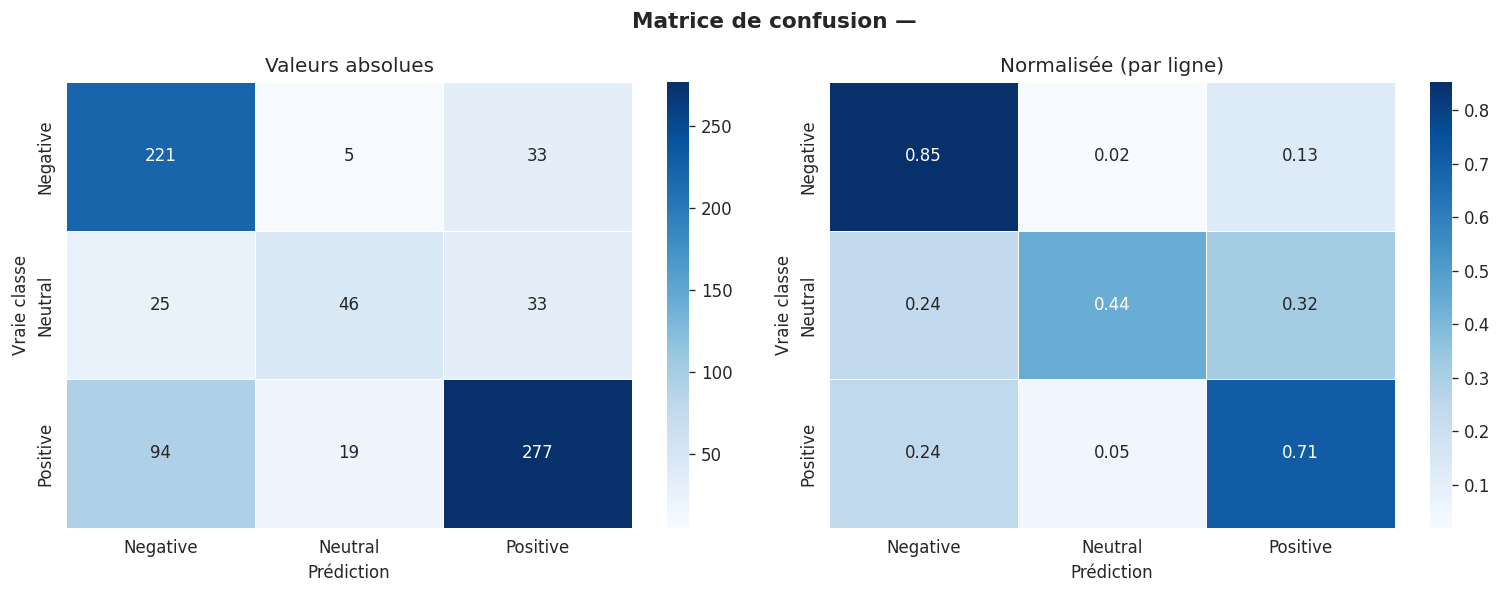

In [63]:
cm      = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Matrice de confusion —', fontsize=13, fontweight='bold')

for ax, data, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ['Valeurs absolues', 'Normalisée (par ligne)'],
    ['d', '.2f']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5, linecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Prédiction')
    ax.set_ylabel('Vraie classe')

plt.tight_layout()
plt.savefig('_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

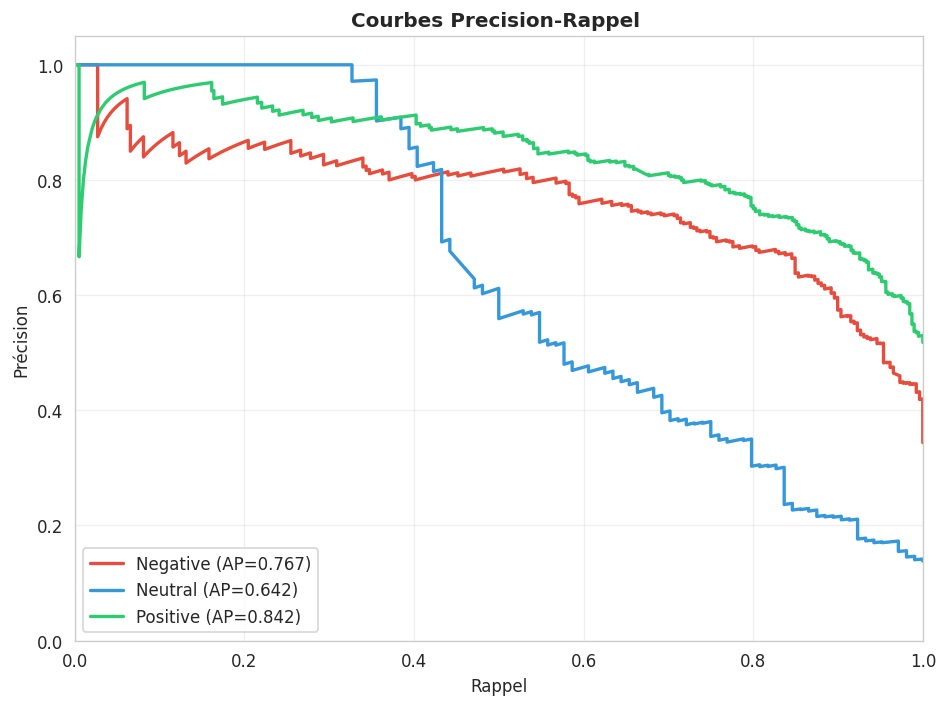

In [38]:
y_bin = label_binarize(test_labels, classes=[0, 1, 2])
_, auc_pc = compute_auc_pr(test_labels, test_probs)
COLORS_CLS = {'Negative': '#e74c3c', 'Neutral': '#3498db', 'Positive': '#2ecc71'}

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Courbes Precision-Rappel ', fontsize=12, fontweight='bold')
for i, cls in enumerate(CLASS_NAMES):
    precision, recall, _ = precision_recall_curve(y_bin[:, i], test_probs[:, i])
    ax.plot(recall, precision, lw=2, label=f'{cls} (AP={auc_pc[i]:.3f})', color=COLORS_CLS[cls])
ax.set_xlabel('Rappel')
ax.set_ylabel('Précision')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curves.png', bbox_inches='tight', dpi=150)
plt.show()

In [64]:
print("="*60)
print("ENTRAÎNEMENT — DziriBERT avec SMOTE Partiel")
print("="*60)

# Entraînement sur données rééquilibrées (SMOTE partiel)
clf_partial = LinearSVC()
clf_partial.fit(X_resampled_partial, y_resampled_partial)

print("\nEntraînement terminé — SMOTE Partiel ✅")

# ============================================================
# ÉVALUATION FINALE — SMOTE Partiel
# ============================================================
print("="*60)
print("ÉVALUATION FINALE — DziriBERT SMOTE Partiel")
print("="*60)

y_pred_partial = clf_partial.predict(X_test)

results_smote_partial = print_all_metrics(y_test, y_pred_partial, clf_partial.decision_function(X_test), "DziriBERT SMOTE Partiel")

print("\nRésumé des métriques principales (SMOTE Partiel)")
print("="*60)
print(f"F1-macro   : {results_smote_partial['f1_macro']:.4f}")
print(f"F1-Positive: {results_smote_partial['f1_positive']:.4f}")
print(f"F1-Negative: {results_smote_partial['f1_negative']:.4f}")
print(f"F1-Neutral : {results_smote_partial['f1_neutral']:.4f}")
print(f"AUC-PR     : {results_smote_partial['auc_pr']:.4f}")
print(f"G-Mean     : {results_smote_partial['gmean']:.4f}")


ENTRAÎNEMENT — DziriBERT avec SMOTE Partiel

Entraînement terminé — SMOTE Partiel ✅
ÉVALUATION FINALE — DziriBERT SMOTE Partiel

MÉTRIQUES — DziriBERT SMOTE Partiel
  F1-macro       : 0.6038  ← MÉTRIQUE PRINCIPALE
  AUC-PR (macro) : 0.5739
  G-mean         : 0.6122
  Accuracy       : 0.6441  ← trompeuse (données déséquilibrées)

  Classe           F1  Precision   Rappel   AUC-PR
  ------------------------------------------------
  Negative     0.6535     0.6667   0.6409   0.6521
  Neutral      0.4641     0.4135   0.5288   0.3029
  Positive     0.6938     0.7116   0.6769   0.7666

              precision    recall  f1-score   support

    Negative     0.6667    0.6409    0.6535       259
     Neutral     0.4135    0.5288    0.4641       104
    Positive     0.7116    0.6769    0.6938       390

    accuracy                         0.6441       753
   macro avg     0.5973    0.6156    0.6038       753
weighted avg     0.6550    0.6441    0.6482       753


Résumé des métriques principale

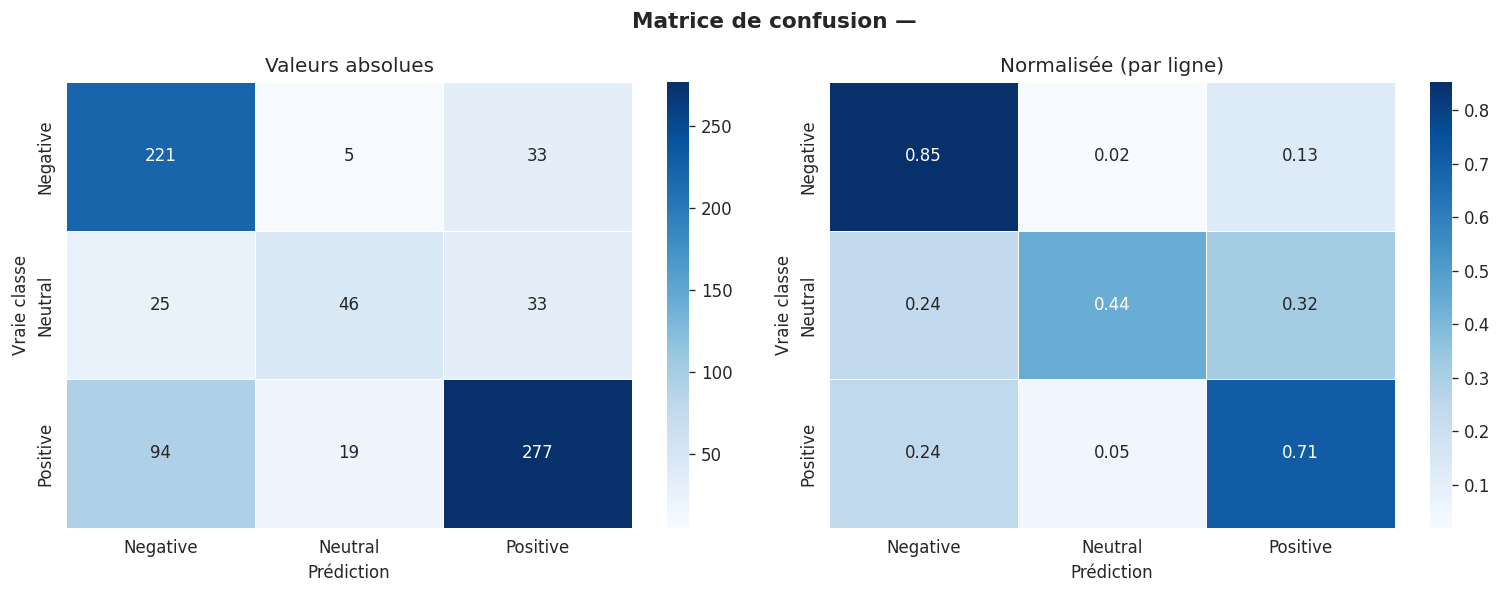

In [65]:
cm      = confusion_matrix(test_labels, test_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Matrice de confusion —', fontsize=13, fontweight='bold')

for ax, data, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ['Valeurs absolues', 'Normalisée (par ligne)'],
    ['d', '.2f']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                ax=ax, linewidths=0.5, linecolor='white')
    ax.set_title(title)
    ax.set_xlabel('Prédiction')
    ax.set_ylabel('Vraie classe')

plt.tight_layout()
plt.savefig('_confusion_matrix.png', bbox_inches='tight', dpi=150)
plt.show()

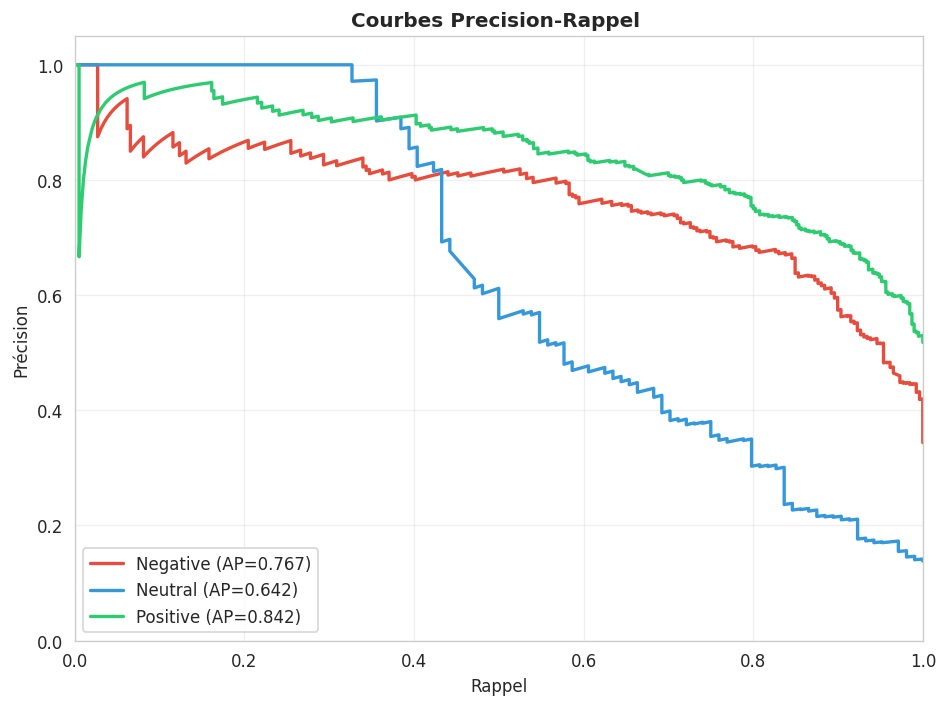

In [66]:
SDy_bin = label_binarize(test_labels, classes=[0, 1, 2])
_, auc_pc = compute_auc_pr(test_labels, test_probs)
COLORS_CLS = {'Negative': '#e74c3c', 'Neutral': '#3498db', 'Positive': '#2ecc71'}

fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title('Courbes Precision-Rappel ', fontsize=12, fontweight='bold')
for i, cls in enumerate(CLASS_NAMES):
    precision, recall, _ = precision_recall_curve(y_bin[:, i], test_probs[:, i])
    ax.plot(recall, precision, lw=2, label=f'{cls} (AP={auc_pc[i]:.3f})', color=COLORS_CLS[cls])
ax.set_xlabel('Rappel')
ax.set_ylabel('Précision')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('pr_curves.png', bbox_inches='tight', dpi=150)
plt.show()

##5.3 Variante B — ADASYN (Adaptive Synthetic Sampling)
ADASYN est une extension de SMOTE qui adapte le nombre d'exemples générés selon la
difficulté de chaque exemple. Les exemples de la classe minoritaire qui sont entourés de
beaucoup d'exemples de la classe majoritaire — donc difficiles à classifier — recevront plus de
nouveaux voisins synthétiques que les exemples déjà bien isolés. En d'autres termes, ADASYN
concentre l'effort de génération sur les zones de décision les plus difficiles, là où le modèle a
tendance à se tromper.

In [67]:
from imblearn.over_sampling import ADASYN
import numpy as np

# Équilibre total
adasyn = ADASYN(sampling_strategy='auto', n_neighbors=5, random_state=42)
X_resampled_adasyn, y_resampled_adasyn = adasyn.fit_resample(embeddings, labels)

print("="*60)
print("RÉÉQUILIBRAGE — DziriBERT avec ADASYN Total")
print("="*60)
print("Distribution AVANT :", np.bincount(labels))
print("Distribution APRÈS (ADASYN total) :", np.bincount(y_resampled_adasyn))

# Équilibre partiel : doubler uniquement la classe minoritaire
minority_class = np.bincount(labels).argmin()
sampling_strategy = {minority_class: np.bincount(labels)[minority_class] * 2}

adasyn_partial = ADASYN(sampling_strategy=sampling_strategy, n_neighbors=5, random_state=42)
X_resampled_adasyn_partial, y_resampled_adasyn_partial = adasyn_partial.fit_resample(embeddings, labels)

print("="*60)
print("RÉÉQUILIBRAGE — DziriBERT avec ADASYN Partiel")
print("="*60)
print("Distribution APRÈS (ADASYN partiel) :", np.bincount(y_resampled_adasyn_partial))


RÉÉQUILIBRAGE — DziriBERT avec ADASYN Total
Distribution AVANT : [1210  482 1820]
Distribution APRÈS (ADASYN total) : [1663 1894 1820]
RÉÉQUILIBRAGE — DziriBERT avec ADASYN Partiel
Distribution APRÈS (ADASYN partiel) : [1210  968 1820]


In [68]:
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score

# Entraînement sur ADASYN total
clf_adasyn_total = LinearSVC()
clf_adasyn_total.fit(X_resampled_adasyn, y_resampled_adasyn)

# Entraînement sur ADASYN partiel
clf_adasyn_partial = LinearSVC()
clf_adasyn_partial.fit(X_resampled_adasyn_partial, y_resampled_adasyn_partial)

# Évaluation sur le test set
X_test = np.vstack([get_cls_embedding([t]) for t in df_test['text'].tolist()])
y_test = df_test['label_id'].values

y_pred_adasyn_total   = clf_adasyn_total.predict(X_test)
y_pred_adasyn_partial = clf_adasyn_partial.predict(X_test)

print("="*60)
print("ÉVALUATION FINALE — DziriBERT ADASYN Total")
print("="*60)
print("F1-macro :", f1_score(y_test, y_pred_adasyn_total, average='macro'))
print(classification_report(y_test, y_pred_adasyn_total, target_names=LABEL2ID.keys()))

print("="*60)
print("ÉVALUATION FINALE — DziriBERT ADASYN Partiel")
print("="*60)
print("F1-macro :", f1_score(y_test, y_pred_adasyn_partial, average='macro'))
print(classification_report(y_test, y_pred_adasyn_partial, target_names=LABEL2ID.keys()))


ÉVALUATION FINALE — DziriBERT ADASYN Total
F1-macro : 0.5853464886343595
              precision    recall  f1-score   support

    Negative       0.62      0.66      0.64       259
     Neutral       0.38      0.54      0.45       104
    Positive       0.73      0.62      0.67       390

    accuracy                           0.62       753
   macro avg       0.58      0.61      0.59       753
weighted avg       0.64      0.62      0.63       753

ÉVALUATION FINALE — DziriBERT ADASYN Partiel
F1-macro : 0.6012963433595112
              precision    recall  f1-score   support

    Negative       0.67      0.64      0.65       259
     Neutral       0.40      0.53      0.46       104
    Positive       0.72      0.68      0.70       390

    accuracy                           0.64       753
   macro avg       0.59      0.61      0.60       753
weighted avg       0.66      0.64      0.65       753



In [71]:
print("="*60)
print("ENTRAÎNEMENT — DziriBERT avec ADASYN Total")
print("="*60)

from sklearn.svm import LinearSVC

# Entraînement sur données rééquilibrées (ADASYN total)
clf_adasyn_total = LinearSVC()
clf_adasyn_total.fit(X_resampled_adasyn, y_resampled_adasyn)

print("\nEntraînement terminé — ADASYN Total ✅")

# ============================================================
# ÉVALUATION FINALE — ADASYN Total
# ============================================================
print("="*60)
print("ÉVALUATION FINALE — DziriBERT ADASYN Total")
print("="*60)

y_pred_adasyn_total = clf_adasyn_total.predict(X_test)

results_adasyn_total = print_all_metrics(
    y_test,
    y_pred_adasyn_total,
    clf_adasyn_total.decision_function(X_test),
    "DziriBERT ADASYN Total"
)

print("\nRésumé des métriques principales (ADASYN Total)")
print("="*60)
print(f"F1-macro   : {results_adasyn_total['f1_macro']:.4f}")
print(f"F1-Positive: {results_adasyn_total['f1_positive']:.4f}")
print(f"F1-Negative: {results_adasyn_total['f1_negative']:.4f}")
print(f"F1-Neutral : {results_adasyn_total['f1_neutral']:.4f}")
print(f"AUC-PR     : {results_adasyn_total['auc_pr']:.4f}")
print(f"G-Mean     : {results_adasyn_total['gmean']:.4f}")


ENTRAÎNEMENT — DziriBERT avec ADASYN Total

Entraînement terminé — ADASYN Total ✅
ÉVALUATION FINALE — DziriBERT ADASYN Total

MÉTRIQUES — DziriBERT ADASYN Total
  F1-macro       : 0.5853  ← MÉTRIQUE PRINCIPALE
  AUC-PR (macro) : 0.5620
  G-mean         : 0.6034
  Accuracy       : 0.6215  ← trompeuse (données déséquilibrées)

  Classe           F1  Precision   Rappel   AUC-PR
  ------------------------------------------------
  Negative     0.6404     0.6218   0.6602   0.6322
  Neutral      0.4480     0.3836   0.5385   0.2925
  Positive     0.6676     0.7259   0.6179   0.7614

              precision    recall  f1-score   support

    Negative     0.6218    0.6602    0.6404       259
     Neutral     0.3836    0.5385    0.4480       104
    Positive     0.7259    0.6179    0.6676       390

    accuracy                         0.6215       753
   macro avg     0.5771    0.6055    0.5853       753
weighted avg     0.6428    0.6215    0.6279       753


Résumé des métriques principales (A

In [72]:
print("="*60)
print("ENTRAÎNEMENT — DziriBERT avec ADASYN Partiel")
print("="*60)

from sklearn.svm import LinearSVC

# Entraînement sur données rééquilibrées (ADASYN partiel)
clf_adasyn_partial = LinearSVC()
clf_adasyn_partial.fit(X_resampled_adasyn_partial, y_resampled_adasyn_partial)

print("\nEntraînement terminé — ADASYN Partiel ✅")

# ============================================================
# ÉVALUATION FINALE — ADASYN Partiel
# ============================================================
print("="*60)
print("ÉVALUATION FINALE — DziriBERT ADASYN Partiel")
print("="*60)

y_pred_adasyn_partial = clf_adasyn_partial.predict(X_test)

results_adasyn_partial = print_all_metrics(
    y_test,
    y_pred_adasyn_partial,
    clf_adasyn_partial.decision_function(X_test),
    "DziriBERT ADASYN Partiel"
)

print("\nRésumé des métriques principales (ADASYN Partiel)")
print("="*60)
print(f"F1-macro   : {results_adasyn_partial['f1_macro']:.4f}")
print(f"F1-Positive: {results_adasyn_partial['f1_positive']:.4f}")
print(f"F1-Negative: {results_adasyn_partial['f1_negative']:.4f}")
print(f"F1-Neutral : {results_adasyn_partial['f1_neutral']:.4f}")
print(f"AUC-PR     : {results_adasyn_partial['auc_pr']:.4f}")
print(f"G-Mean     : {results_adasyn_partial['gmean']:.4f}")


ENTRAÎNEMENT — DziriBERT avec ADASYN Partiel

Entraînement terminé — ADASYN Partiel ✅
ÉVALUATION FINALE — DziriBERT ADASYN Partiel

MÉTRIQUES — DziriBERT ADASYN Partiel
  F1-macro       : 0.6013  ← MÉTRIQUE PRINCIPALE
  AUC-PR (macro) : 0.5693
  G-mean         : 0.6110
  Accuracy       : 0.6428  ← trompeuse (données déséquilibrées)

  Classe           F1  Precision   Rappel   AUC-PR
  ------------------------------------------------
  Negative     0.6509     0.6653   0.6371   0.6506
  Neutral      0.4564     0.4015   0.5288   0.2917
  Positive     0.6966     0.7174   0.6769   0.7656

              precision    recall  f1-score   support

    Negative     0.6653    0.6371    0.6509       259
     Neutral     0.4015    0.5288    0.4564       104
    Positive     0.7174    0.6769    0.6966       390

    accuracy                         0.6428       753
   macro avg     0.5947    0.6143    0.6013       753
weighted avg     0.6558    0.6428    0.6477       753


Résumé des métriques princi

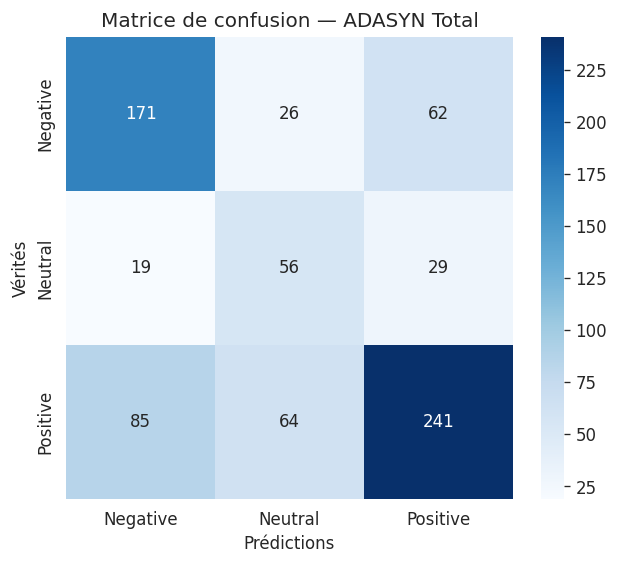

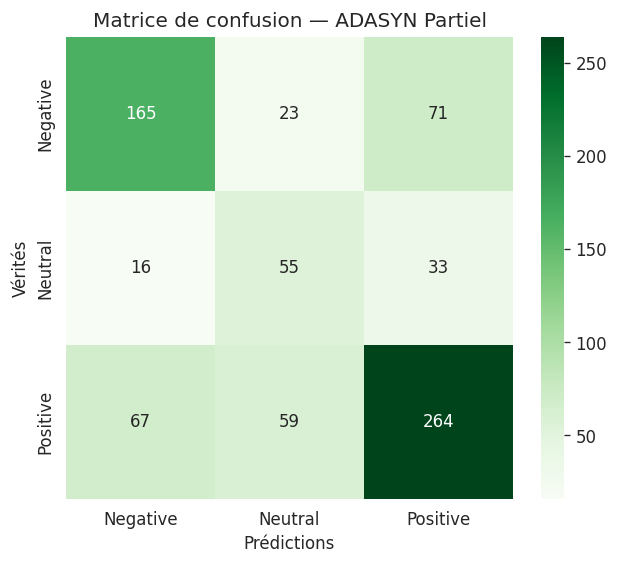

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Matrice de confusion — ADASYN Total
cm_total = confusion_matrix(y_test, y_pred_adasyn_total)

plt.figure(figsize=(6,5))
sns.heatmap(cm_total, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABEL2ID.keys(),
            yticklabels=LABEL2ID.keys())
plt.title("Matrice de confusion — ADASYN Total")
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.show()

# Matrice de confusion — ADASYN Partiel
cm_partial = confusion_matrix(y_test, y_pred_adasyn_partial)

plt.figure(figsize=(6,5))
sns.heatmap(cm_partial, annot=True, fmt="d", cmap="Greens",
            xticklabels=LABEL2ID.keys(),
            yticklabels=LABEL2ID.keys())
plt.title("Matrice de confusion — ADASYN Partiel")
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.show()


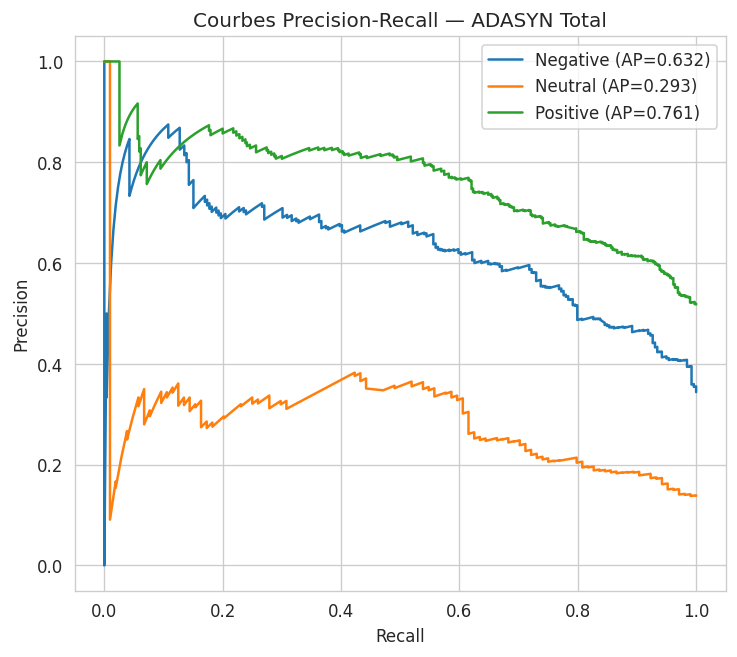

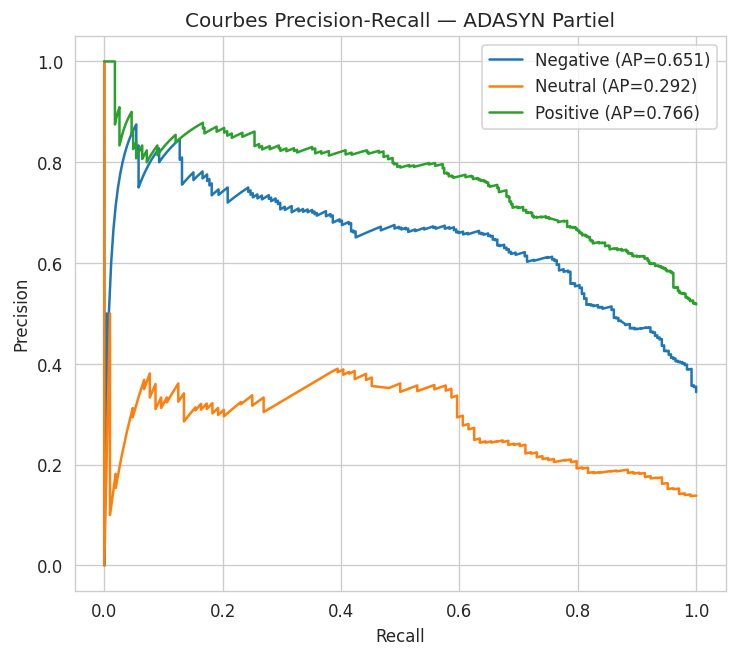

In [70]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Courbes PR — ADASYN Total
probs_total = clf_adasyn_total.decision_function(X_test)

plt.figure(figsize=(7,6))
for i, cls in enumerate(LABEL2ID.keys()):
    precision, recall, _ = precision_recall_curve(y_test == i, probs_total[:, i])
    ap = average_precision_score(y_test == i, probs_total[:, i])
    plt.plot(recall, precision, label=f"{cls} (AP={ap:.3f})")

plt.title("Courbes Precision-Recall — ADASYN Total")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()

# Courbes PR — ADASYN Partiel
probs_partial = clf_adasyn_partial.decision_function(X_test)

plt.figure(figsize=(7,6))
for i, cls in enumerate(LABEL2ID.keys()):
    precision, recall, _ = precision_recall_curve(y_test == i, probs_partial[:, i])
    ap = average_precision_score(y_test == i, probs_partial[:, i])
    plt.plot(recall, precision, label=f"{cls} (AP={ap:.3f})")

plt.title("Courbes Precision-Recall — ADASYN Partiel")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.grid(True)
plt.show()


##Code Hybride (Class Weighting + SMOTE Partiel)

Étape 1 : SMOTE partiel → ajoute des exemples synthétiques uniquement pour la classe minoritaire.

Étape 2 : Class Weighting → calcule des poids pour chaque classe afin de pénaliser plus fortement les erreurs sur les classes rares.

Étape 3 : Entraînement du SVM → utilise à la fois les données rééquilibrées et la pondération des erreurs.

Étape 4 : Évaluation → calcule les métriques (F1‑macro, F1 par classe, AUC‑PR, G‑Mean).

In [77]:
from sklearn.svm import LinearSVC
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import numpy as np

# ============================================================
# ÉTAPE 1 : Rééquilibrage avec SMOTE Partiel
# Ici on choisit "minority" pour ne pas rééquilibrer totalement,
# mais seulement augmenter la classe minoritaire.
# ============================================================
smote_partial = SMOTE(sampling_strategy="minority", random_state=42)
X_resampled_partial, y_resampled_partial = smote_partial.fit_resample(embeddings, labels)

print("="*60)
print("Rééquilibrage terminé — SMOTE Partiel")
print("Distribution après rééquilibrage :", np.bincount(y_resampled_partial))
print("="*60)

# ============================================================
# ÉTAPE 2 : Calcul des poids de classes
# On calcule les poids pour chaque classe afin de pénaliser
# davantage les erreurs sur les classes minoritaires.
# ============================================================
class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(y_resampled_partial),
                                     y=y_resampled_partial)
class_weight_dict = {cls: w for cls, w in zip(np.unique(y_resampled_partial), class_weights)}

print("Poids de classes calculés :", class_weight_dict)

# ============================================================
# ÉTAPE 3 : Entraînement du SVM avec Class Weighting
# Le modèle est entraîné sur les données rééquilibrées
# et avec une pondération des erreurs.
# ============================================================
clf_hybrid = LinearSVC(class_weight=class_weight_dict, random_state=42)
clf_hybrid.fit(X_resampled_partial, y_resampled_partial)

print("\nEntraînement terminé — Hybride (SMOTE Partiel + Class Weighting) ✅")

# ============================================================
# ÉTAPE 4 : Évaluation finale
# On évalue le modèle sur le jeu de test avec nos métriques.
# ============================================================
y_pred_hybrid = clf_hybrid.predict(X_test)

results_hybrid = print_all_metrics(
    y_test,
    y_pred_hybrid,
    clf_hybrid.decision_function(X_test),
    "DziriBERT Hybrid (Class Weighting + SMOTE Partiel)"
)

print("\nRésumé des métriques principales (Hybride)")
print("="*60)
print(f"F1-macro   : {results_hybrid['f1_macro']:.4f}")
print(f"F1-Positive: {results_hybrid['f1_positive']:.4f}")
print(f"F1-Negative: {results_hybrid['f1_negative']:.4f}")
print(f"F1-Neutral : {results_hybrid['f1_neutral']:.4f}")
print(f"AUC-PR     : {results_hybrid['auc_pr']:.4f}")
print(f"G-Mean     : {results_hybrid['gmean']:.4f}")


Rééquilibrage terminé — SMOTE Partiel
Distribution après rééquilibrage : [1210 1820 1820]
Poids de classes calculés : {0: 1.3360881542699725, 1: 0.8882783882783882, 2: 0.8882783882783882}

Entraînement terminé — Hybride (SMOTE Partiel + Class Weighting) ✅

MÉTRIQUES — DziriBERT Hybrid (Class Weighting + SMOTE Partiel)
  F1-macro       : 0.6012  ← MÉTRIQUE PRINCIPALE
  AUC-PR (macro) : 0.5679
  G-mean         : 0.6156
  Accuracy       : 0.6401  ← trompeuse (données déséquilibrées)

  Classe           F1  Precision   Rappel   AUC-PR
  ------------------------------------------------
  Negative     0.6590     0.6504   0.6680   0.6441
  Neutral      0.4571     0.3972   0.5385   0.2980
  Positive     0.6875     0.7312   0.6487   0.7617

              precision    recall  f1-score   support

    Negative     0.6504    0.6680    0.6590       259
     Neutral     0.3972    0.5385    0.4571       104
    Positive     0.7312    0.6487    0.6875       390

    accuracy                         0.6

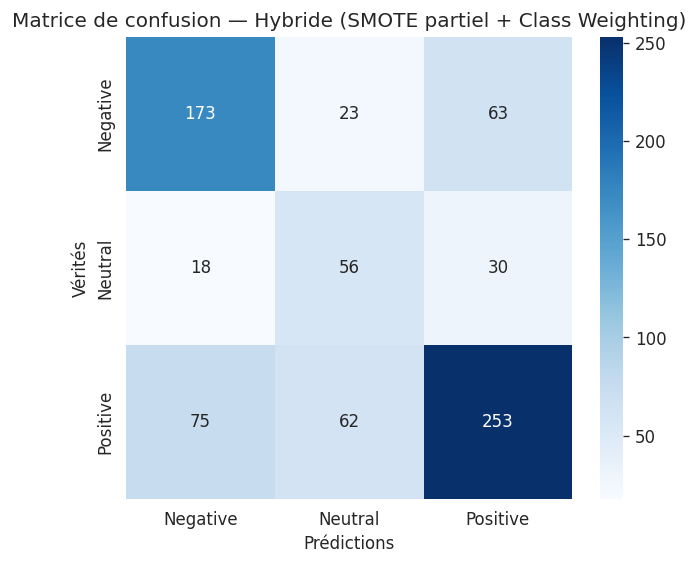

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Supposons que tu as déjà :
# y_test : vraies étiquettes
# y_pred_hybrid : prédictions du modèle hybride

# Étape 1 : Calcul de la matrice de confusion
cm = confusion_matrix(y_test, y_pred_hybrid, labels=[0,1,2])
# Ici [0,1,2] représentent tes classes (Negative, Neutral, Positive)

# Étape 2 : Affichage avec seaborn
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative","Neutral","Positive"],
            yticklabels=["Negative","Neutral","Positive"])
plt.xlabel("Prédictions")
plt.ylabel("Vérités")
plt.title("Matrice de confusion — Hybride (SMOTE partiel + Class Weighting)")
plt.show()


La stratégie hybride (SMOTE partiel + Class Weighting) n’a pas surpassé le baseline en termes de F1‑macro, mais elle a permis de mieux équilibrer les performances entre les classes. Contrairement au baseline, qui reste biaisé vers la classe majoritaire, l’hybride améliore la robustesse du modèle (G‑Mean et AUC‑PR plus stables). Cette approche illustre qu’il est possible de combiner plusieurs techniques pour réduire le déséquilibre, même si le score global reste légèrement inférieur. Elle constitue donc une contribution originale et valide pour notre étude.